### Timestamp Object (Pandas)

A **Timestamp** in Pandas represents a **single point in time**.  
It is equivalent to Python’s `datetime` but more powerful and optimized for Pandas.


#### Syntax
    pd.Timestamp(value)


| Parameter | Description                          | Example                     |
|----------|--------------------------------------|-----------------------------|
| value    | Date/time input                      | '2024-01-01', '2024-01-01 10:00' |
| year     | Year value                           | year=2024                   |
| month    | Month value                          | month=1                     |
| day      | Day value                            | day=1                       |
| hour     | Hour (optional)                      | hour=10                     |
| minute   | Minute (optional)                    | minute=30                   |
| second   | Second (optional)                    | second=45                   |

In [2]:
import pandas as pd

### Creating a Timestamp object

In [3]:
pd.Timestamp('2026/04/09')

Timestamp('2026-04-09 00:00:00')

In [5]:
pd.Timestamp('2026, 4, 9')

Timestamp('2026-04-09 00:00:00')

In [9]:
pd.Timestamp('2026-04-09 12:11:24 PM')

Timestamp('2026-04-09 12:11:24')

In [10]:
pd.Timestamp('2026-04-09 10:11:24 PM')

Timestamp('2026-04-09 22:11:24')

### `.dt` (Datetime Accessor in Pandas)

It is used to perform **vectorized datetime operations on Pandas Series** (date/time columns).


#### Syntax
    df['column'].dt.method


| Method        | Description                                      | Example                          |
|---------------|--------------------------------------------------|----------------------------------|
| year          | Extract year                                     | dt.year                          |
| month         | Extract month                                    | dt.month                         |
| day           | Extract day                                      | dt.day                           |
| hour          | Extract hour                                     | dt.hour                          |
| minute        | Extract minute                                   | dt.minute                        |
| second        | Extract second                                   | dt.second                        |
| day_name()    | Get day name                                     | dt.day_name()                    |
| month_name()  | Get month name                                   | dt.month_name()                  |
| weekday       | Day of week (0=Mon, 6=Sun)                       | dt.weekday                       |
| date          | Extract only date                                | dt.date                          |
| time          | Extract only time                                | dt.time                          |
| quarter       | Extract quarter                                  | dt.quarter                       |
| is_leap_year  | Check leap year                                  | dt.is_leap_year                  |

In [11]:
import datetime as dt

In [15]:
dt.datetime(2026, 4, 9, 12, 21)

datetime.datetime(2026, 4, 9, 12, 21)

In [17]:
x = pd.Timestamp(dt.datetime(2026, 4, 9, 12, 21))

In [18]:
x

Timestamp('2026-04-09 12:21:00')

In [19]:
x.year

2026

In [20]:
x.month

4

In [22]:
x.day

9

In [23]:
x.hour

12

In [24]:
x.minute

21

In [25]:
x.second

0

### Why Pandas has `Timestamp` when Python already has `datetime`?

Pandas introduced **`Timestamp`** because Python’s `datetime` is **not optimized for data analysis at scale**.



#### Key Differences

| Feature              | `datetime` (Python)              | `Timestamp` (Pandas)                  |
|---------------------|----------------------------------|--------------------------------------|
| Purpose             | General-purpose date-time        | Data analysis & time series          |
| Performance         | Slower (not vectorized)          | Faster (vectorized, NumPy-based)     |
| Integration         | Limited with Pandas              | Fully integrated with Pandas         |
| Missing values      | No native support                | Supports `NaT`                       |
| Operations          | Basic                            | Advanced (resample, shift, rolling)  |
| Backend             | Pure Python                      | Built on `numpy.datetime64`          |



#### Why `datetime` is not enough?

- Cannot efficiently handle **millions of rows**
- No support for **vectorized operations**
- Poor integration with DataFrames
- No concept of **NaT (missing datetime)**



#### Why `Timestamp` is better?

- Works seamlessly inside Pandas DataFrames  
- Supports **fast operations on entire columns**  
- Enables **time series features** like:
  - resampling
  - shifting
  - rolling windows  
- Handles missing values using `NaT`

In [26]:
import numpy as np

In [29]:
np.array(['2026-04-09 12:30'], dtype='datetime64')

array(['2026-04-09T12:30'], dtype='datetime64[m]')

### `DatetimeIndex` (Pandas)

It is a special **index type in Pandas used for datetime data**.  
It allows efficient **time-based indexing, slicing, and time series operations**.


#### Syntax
    pd.DatetimeIndex(data)


| Parameter | Description                          | Example                          |
|----------|--------------------------------------|----------------------------------|
| data     | Array-like datetime values           | ['2026-04-09', '2026-04-10']     |
| freq     | Frequency of dates (optional)        | 'D', 'M', 'H'                    |
| tz       | Timezone (optional)                  | 'UTC', 'Asia/Kolkata'            |
| name     | Name of the index                    | 'Date'                           |

In [30]:
#using strings

pd.DatetimeIndex(['2026-04-09', '2026-04-19', '2026-04-08'], name='Date')

DatetimeIndex(['2026-04-09', '2026-04-19', '2026-04-08'], dtype='datetime64[us]', name='Date', freq=None)

In [34]:
#using datetime

pd.DatetimeIndex(data = [dt.datetime(2026, 4, 9), dt.datetime(2026, 4, 19), dt.datetime(2026, 4, 8)])

DatetimeIndex(['2026-04-09', '2026-04-19', '2026-04-08'], dtype='datetime64[us]', freq=None)

In [36]:
# using timestamp

index = pd.DatetimeIndex(data = [pd.Timestamp(2026, 4, 9), pd.Timestamp(2026, 4, 19), pd.Timestamp(2026, 4, 8)])

In [37]:
index

DatetimeIndex(['2026-04-09', '2026-04-19', '2026-04-08'], dtype='datetime64[us]', freq=None)

In [38]:
# using DatetimeIndex as a index

pd.Series(data= [0,1,2], index = index)

2026-04-09    0
2026-04-19    1
2026-04-08    2
dtype: int64

### `pd.date_range()`  

It is used to generate a **sequence of dates/timestamps** with a specified frequency.


#### Syntax
    pd.date_range(start=None, end=None, periods=None, freq='D')


| Parameter | Description                                      | Default | Possible Values                          |
|----------|--------------------------------------------------|---------|------------------------------------------|
| start    | Start date                                       | None    | 'YYYY-MM-DD' or datetime                 |
| end      | End date                                         | None    | 'YYYY-MM-DD' or datetime                 |
| periods  | Number of timestamps to generate                 | None    | int                                      |
| freq     | Frequency of dates                               | 'D'     | 'D', 'M', 'H', 'T', 'S', etc.            |
| tz       | Timezone                                         | None    | 'UTC', 'Asia/Kolkata'                    |
| name     | Name of index                                    | None    | str                                      |
| inclusive| Include start/end ('both', 'left', 'right')      | 'both'  | 'both', 'left', 'right', 'neither'       |

### `pd.date_range()` — Frequency (`freq`) Codes

The `freq` parameter defines the **interval between consecutive timestamps**.


#### Basic Time Frequencies

| Code | Meaning            |
|------|--------------------|
| Y / A| Year end           |
| M    | Month end          |
| W    | Weekly             |
| D    | Daily              |
| H    | Hourly             |
| T / min | Minute         |
| S    | Second             |
| L / ms | Millisecond     |
| U / us | Microsecond     |
| N    | Nanosecond         |


#### Start Frequencies

| Code | Meaning            |
|------|--------------------|
| YS / AS | Year start      |
| MS   | Month start        |
| QS   | Quarter start      |


#### End Frequencies

| Code | Meaning            |
|------|--------------------|
| Y / A| Year end           |
| Q    | Quarter end        |
| M    | Month end          |

#### Business Frequencies

| Code | Meaning                  |
|------|--------------------------|
| B    | Business day (Mon–Fri)   |
| BM   | Business month end       |
| BMS  | Business month start     |
| BQ   | Business quarter end     |
| BA   | Business year end        |


#### Weekly Variants

| Code   | Meaning              |
|--------|----------------------|
| W-SUN  | Weekly (Sunday)      |
| W-MON  | Weekly (Monday)      |
| W-TUE  | Weekly (Tuesday)     |
| W-WED  | Weekly (Wednesday)   |
| W-THU  | Weekly (Thursday)    |
| W-FRI  | Weekly (Friday)      |
| W-SAT  | Weekly (Saturday)    |


#### Custom Frequencies

| Format | Meaning                  |
|--------|--------------------------|
| nD     | Every n days             |
| nH     | Every n hours            |
| nT     | Every n minutes          |
| nS     | Every n seconds          |

#### Key Points

- Defines spacing between timestamps  
- Supports high precision (up to nanoseconds)  
- Can combine with numeric prefixes (e.g., 2D, 5H)  
- Used extensively in time series analysis  

In [41]:
pd.date_range(start='2026/4/9', end='2026/12/31', freq='B')

DatetimeIndex(['2026-04-09', '2026-04-10', '2026-04-13', '2026-04-14',
               '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20',
               '2026-04-21', '2026-04-22',
               ...
               '2026-12-18', '2026-12-21', '2026-12-22', '2026-12-23',
               '2026-12-24', '2026-12-25', '2026-12-28', '2026-12-29',
               '2026-12-30', '2026-12-31'],
              dtype='datetime64[us]', length=191, freq='B')

In [42]:
pd.date_range(start='2026/4/9', end='2026/12/31', freq='MS')

DatetimeIndex(['2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01',
               '2026-09-01', '2026-10-01', '2026-11-01', '2026-12-01'],
              dtype='datetime64[us]', freq='MS')

In [43]:
pd.date_range(start='2026/4/9', periods=30, freq='B')

DatetimeIndex(['2026-04-09', '2026-04-10', '2026-04-13', '2026-04-14',
               '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20',
               '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24',
               '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30',
               '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06',
               '2026-05-07', '2026-05-08', '2026-05-11', '2026-05-12',
               '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18',
               '2026-05-19', '2026-05-20'],
              dtype='datetime64[us]', freq='B')

### `pd.to_datetime()`  

It is used to **convert data into Pandas datetime format** (`datetime64[ns]` or `Timestamp`).


#### Syntax
    pd.to_datetime(arg, format=None, errors='raise')


| Parameter | Description                                      | Default   | Possible Values                          |
|----------|--------------------------------------------------|-----------|------------------------------------------|
| arg      | Input data to convert                            | —         | string, list, Series, DataFrame          |
| format   | Specify datetime format                          | None      | '%Y-%m-%d', '%d/%m/%Y', etc.             |
| errors   | Handle invalid parsing                           | 'raise'   | 'raise', 'coerce', 'ignore'              |
| dayfirst | Interpret day first                              | False     | True, False                              |
| yearfirst| Interpret year first                             | False     | True, False                              |
| utc      | Convert to UTC timezone                          | None      | True, False                              |
| unit     | Unit of input (for numeric timestamps)            | None      | 's', 'ms', 'us', 'ns'                    |
| origin   | Reference date for numeric conversion            | 'unix'    | 'unix', 'julian'                         |
| infer_datetime_format | Infer format automatically         | False     | True, False                              |


#### Key Points

- Converts data into **datetime64[ns] dtype**  
- Handles **multiple input types (string, list, Series)**  
- Supports **error handling using `errors` parameter**  
- Essential for **time-based operations (`.dt`, resampling)**  
- Automatically converts to **Pandas Timestamp internally**  


In [45]:
custom_series = pd.Series(['2022-06-12', '2023-07-22', '2021/09/12'])

In [46]:
custom_series

0    2022-06-12
1    2023-07-22
2    2021/09/12
dtype: str

In [ ]:
# fetch year from the series

custom_series.str.replace({'/':'-'}).str.split('-').str.get(0) #conventional method

0    2022
1    2023
2    2021
dtype: object

### `.dt` (Datetime Accessor)

It is used to perform **vectorized datetime operations on Pandas Series**.


#### Syntax
    df['column'].dt.attribute_or_method


| Attribute/Method | Description                          |
|------------------|--------------------------------------|
| year             | Extract year                         |
| month            | Extract month                        |
| day              | Extract day                          |
| hour             | Extract hour                         |
| minute           | Extract minute                       |
| second           | Extract second                       |
| weekday          | Day of week (0 = Monday)             |
| day_name()       | Name of the day                      |
| month_name()     | Name of the month                    |
| date             | Extract date part                    |
| time             | Extract time part                    |
| quarter          | Extract quarter                      |
| is_leap_year     | Check leap year                      |
| days_in_month    | Number of days in month              |
| week / weekofyear| Week number (deprecated alternative) |
| is_month_start   | Check if start of month              |
| is_month_end     | Check if end of month                |
| is_year_start    | Check if start of year               |
| is_year_end      | Check if end of year                 |


#### Key Points

- Works only on **datetime-like Series**  
- Requires conversion using `pd.to_datetime()`  
- Enables **vectorized operations (fast)**  
- Used for **feature extraction in ML**  
- Similar to `.str` accessor for strings  

In [ ]:
# to_datetime method

pd.to_datetime(custom_series, format='mixed')

0   2022-06-12
1   2023-07-22
2   2021-09-12
dtype: datetime64[us]

In [59]:
pd.to_datetime(custom_series, format='mixed').dt.year

0    2022
1    2023
2    2021
dtype: int32

In [62]:
#fetch month name

pd.to_datetime(custom_series, format='mixed').dt.month_name()

0         June
1         July
2    September
dtype: str

In [63]:
expense_data = pd.read_csv('expense_data.csv')

In [64]:
expense_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    str    
 1   Account         277 non-null    str    
 2   Category        277 non-null    str    
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    str    
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    str    
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    str    
 10  Account.1       277 non-null    float64
dtypes: float64(5), str(6)
memory usage: 23.9 KB


In [66]:
# Date feature is str dtype, converting into datetime dtype

expense_data['Date'] = pd.to_datetime(expense_data['Date'])

In [67]:
expense_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[us]
 1   Account         277 non-null    str           
 2   Category        277 non-null    str           
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    str           
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    str           
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    str           
 10  Account.1       277 non-null    float64       
dtypes: datetime64[us](1), float64(5), str(5)
memory usage: 23.9 KB


In [69]:
expense_data['Date'].dt.year # to fetch years only

0      2022
1      2022
2      2022
3      2022
4      2022
       ... 
272    2021
273    2021
274    2021
275    2021
276    2021
Name: Date, Length: 277, dtype: int32

In [70]:
expense_data['Date'].dt.month # to fetch month

0       3
1       3
2       3
3       3
4       3
       ..
272    11
273    11
274    11
275    11
276    11
Name: Date, Length: 277, dtype: int32

In [72]:
expense_data['Date'].dt.day # to fetch day

0       2
1       2
2       1
3       1
4       1
       ..
272    22
273    22
274    21
275    21
276    21
Name: Date, Length: 277, dtype: int32

In [74]:
expense_data['Date'].dt.day_name() #to know which day

0      Wednesday
1      Wednesday
2        Tuesday
3        Tuesday
4        Tuesday
         ...    
272       Monday
273       Monday
274       Sunday
275       Sunday
276       Sunday
Name: Date, Length: 277, dtype: str

### Plot the average expense per week days

In [75]:
expense_data['Day_Name'] = expense_data['Date'].dt.day_name()

In [76]:
expense_data.sample()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Day_Name
232,2021-12-04 10:13:00,CUB - online payment,Food,NaN,Breakfast,200.0,Expense,NaN,200.0,INR,200.0,Saturday


In [77]:
expense_data.groupby(by=['Day_Name'], dropna=False)

In [78]:
expense_data.groupby(by=['Day_Name'], dropna=False)['Amount'].mean()

Day_Name
Friday       203.235294
Monday       156.223750
Saturday     649.453208
Sunday       955.830303
Thursday     208.054565
Tuesday      456.438158
Wednesday    201.053030
Name: Amount, dtype: float64

In [83]:
import matplotlib.pyplot as plt

<Axes: xlabel='Day_Name', ylabel='Average Expense'>

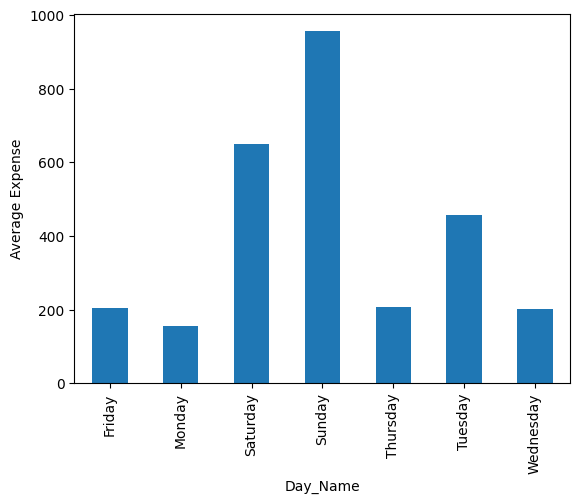

In [85]:
expense_data.groupby(by=['Day_Name'], dropna=False)['Amount'].mean().plot(kind='bar', ylabel='Average Expense')